In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
jobs = pd.read_parquet('db/jobs.parquet')
ratings = pd.read_parquet('db/ratings.parquet')

In [3]:
df = jobs.merge(ratings, how='inner', on='tconst')

In [4]:
contagem_de_filmes = df.groupby(by=['nconst'])['tconst'].count().rename('movieCount')

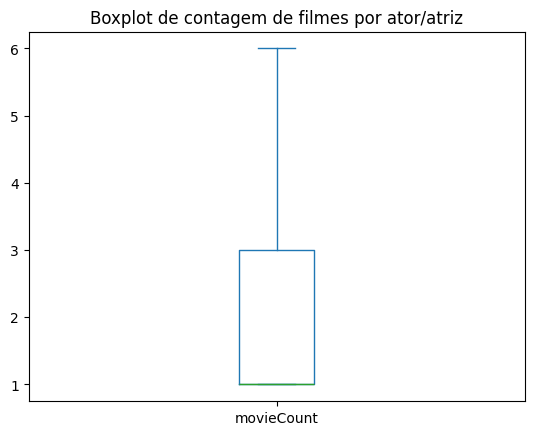

In [5]:
contagem_de_filmes.plot.box(showfliers=False)
plt.title('Boxplot de contagem de filmes por ator/atriz')
plt.show()

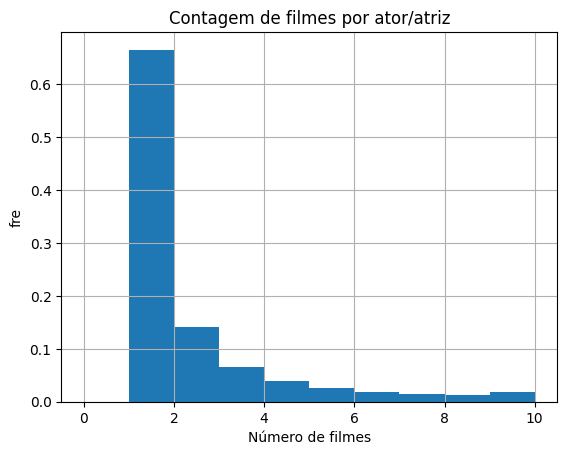

In [6]:
contagem_de_filmes.hist(bins=range(11), density=True)
plt.title('Contagem de filmes por ator/atriz')
plt.xlabel('Número de filmes')
plt.ylabel('fre')
plt.show()

In [7]:
resultado = df.groupby(by=['nconst'])\
              .apply(lambda g: np.average(g['averageRating'], weights=g['numVotes']))

In [8]:
resultado.sort_values(inplace=True)

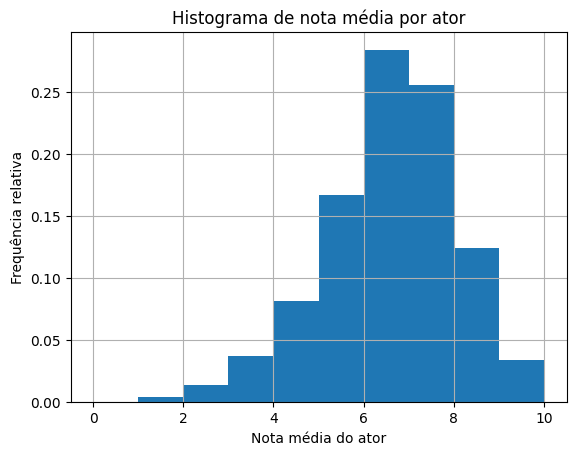

In [9]:
resultado.hist(bins=range(11), density=True)
plt.title('Histograma de nota média por ator')
plt.xlabel('Nota média do ator')
plt.ylabel('Frequência relativa')
plt.show()

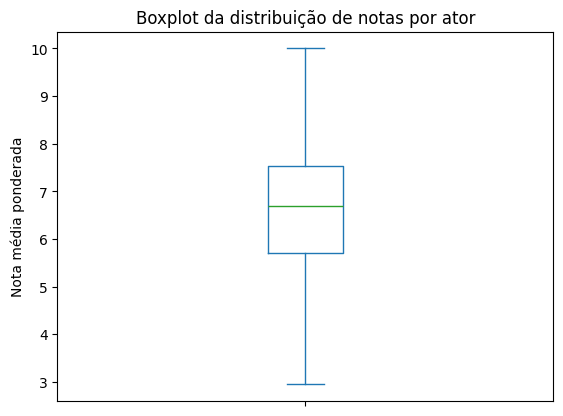

In [10]:
resultado.plot.box(showfliers=False)
plt.title('Boxplot da distribuição de notas por ator')
plt.ylabel('Nota média ponderada')
plt.show()